# Tutrial 5, Question 2b 

In [1]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms

import numpy as np
from numpy import linspace
import matplotlib.pyplot as plt

from common_utils import NeuralNetwork, NeuralNetwork_dropout, EarlyStopper
from common_utils import train_loop, test_loop
from common_utils import device, set_seed

In [2]:
batch_size = 256
max_epochs = 100

patience = 10
lr=0.001

set_seed(0)
print(f"Using {device} device")

Using mps device


In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4)

Epoch 1: Train_accuracy: 41.06%, Train_loss: 0.006517, Test_accuracy: 46.60%, Test_loss: 0.005992
Epoch 2: Train_accuracy: 49.77%, Train_loss: 0.005564, Test_accuracy: 51.17%, Test_loss: 0.005571
Epoch 3: Train_accuracy: 54.11%, Train_loss: 0.005097, Test_accuracy: 51.67%, Test_loss: 0.005519
Epoch 4: Train_accuracy: 57.67%, Train_loss: 0.004680, Test_accuracy: 53.74%, Test_loss: 0.005248
Epoch 5: Train_accuracy: 60.66%, Train_loss: 0.004329, Test_accuracy: 52.51%, Test_loss: 0.005476
Epoch 6: Train_accuracy: 63.93%, Train_loss: 0.003972, Test_accuracy: 53.88%, Test_loss: 0.005436
Epoch 7: Train_accuracy: 66.73%, Train_loss: 0.003641, Test_accuracy: 54.22%, Test_loss: 0.005510
Epoch 8: Train_accuracy: 69.75%, Train_loss: 0.003285, Test_accuracy: 55.49%, Test_loss: 0.005567
Epoch 9: Train_accuracy: 73.22%, Train_loss: 0.002923, Test_accuracy: 54.04%, Test_loss: 0.005930
Epoch 10: Train_accuracy: 76.29%, Train_loss: 0.002617, Test_accuracy: 54.44%, Test_loss: 0.006321
Epoch 11: Train_acc

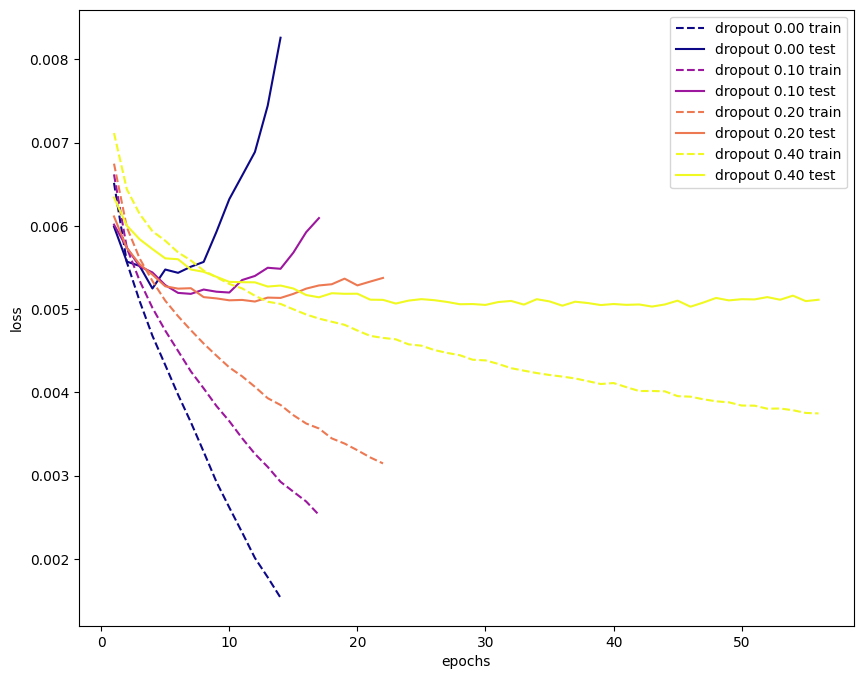

In [4]:
drop_outs = [0.0,0.1, 0.2, 0.4]
loss_fn = nn.CrossEntropyLoss()

fig = plt.figure(figsize=(10,8))
colors = plt.cm.plasma(linspace(0, 1, 4))

for color, drop_out in zip(colors, drop_outs):
    tr_loss, tr_correct = [], []
    te_loss, te_correct = [], []

    early_stopper = EarlyStopper(patience=patience, min_delta=0)
    model = NeuralNetwork_dropout(hidden_size=400, drop_out = drop_out).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for t in range(max_epochs):
        
        model.train()
        train_loss, train_correct = train_loop(train_dataloader, model, loss_fn, optimizer)

        model.eval()
        test_loss, test_correct = test_loop(test_dataloader, model, loss_fn)
    
        tr_loss.append(train_loss), tr_correct.append(train_correct)
        te_loss.append(test_loss), te_correct.append(test_correct)
    
    
        print(f"Epoch {t+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")
    
        if early_stopper.early_stop(test_loss): 
            print("Done!")
            break
    
    plt.plot(range(1,len(tr_loss)+1),tr_loss, linestyle = '--', label='dropout %.2f train'%drop_out, color = color)
    plt.plot(range(1,len(te_loss)+1),te_loss,label='dropout %.2f test'%drop_out, color = color)

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

Epoch 1: Train_accuracy: 40.31%, Train_loss: 0.006545, Test_accuracy: 47.35%, Test_loss: 0.005940
Epoch 2: Train_accuracy: 49.52%, Train_loss: 0.005580, Test_accuracy: 49.53%, Test_loss: 0.005707
Epoch 3: Train_accuracy: 54.09%, Train_loss: 0.005108, Test_accuracy: 51.65%, Test_loss: 0.005462
Epoch 4: Train_accuracy: 57.59%, Train_loss: 0.004702, Test_accuracy: 52.81%, Test_loss: 0.005360
Epoch 5: Train_accuracy: 60.67%, Train_loss: 0.004343, Test_accuracy: 54.05%, Test_loss: 0.005287
Epoch 6: Train_accuracy: 63.71%, Train_loss: 0.003979, Test_accuracy: 54.54%, Test_loss: 0.005430
Epoch 7: Train_accuracy: 66.55%, Train_loss: 0.003667, Test_accuracy: 55.33%, Test_loss: 0.005405
Epoch 8: Train_accuracy: 69.96%, Train_loss: 0.003288, Test_accuracy: 54.47%, Test_loss: 0.005665
Epoch 9: Train_accuracy: 72.91%, Train_loss: 0.002965, Test_accuracy: 55.53%, Test_loss: 0.005824
Epoch 10: Train_accuracy: 75.96%, Train_loss: 0.002623, Test_accuracy: 54.75%, Test_loss: 0.006225
Epoch 11: Train_acc

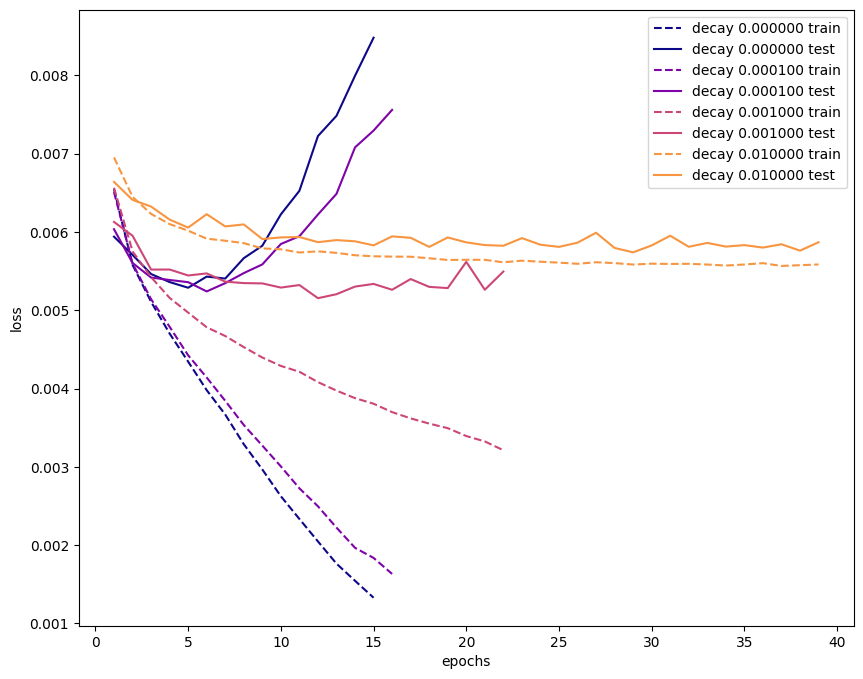

In [ ]:
weight_decays = [0.0, 0.0001, 0.001, 0.01]
loss_fn = nn.CrossEntropyLoss()

fig = plt.figure(figsize=(10,8))
colors = plt.cm.plasma(linspace(0, 1, 5))

for weight_decay, color in zip(weight_decays, colors):
    tr_loss, tr_correct = [], []
    te_loss, te_correct = [], []
    
    early_stopper = EarlyStopper(patience=patience, min_delta=0)
    model = NeuralNetwork(hidden_size=400).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    for t in range(max_epochs):

        train_loss, train_correct = train_loop(train_dataloader, model, loss_fn, optimizer)
        test_loss, test_correct = test_loop(test_dataloader, model, loss_fn)
    
        tr_loss.append(train_loss), tr_correct.append(train_correct)
        te_loss.append(test_loss), te_correct.append(test_correct)
    
        print(f"Epoch {t+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")
    
        if early_stopper.early_stop(test_loss): 
            print("Done!")
            break
    
    plt.plot(range(1,len(tr_loss)+1),tr_loss, linestyle = '--', label='decay %.4f train'%weight_decay, color=color)
    plt.plot(range(1,len(te_loss)+1),te_loss,label='decay %.6f test'%weight_decay, color=color)
    
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()